# Experiment 3 — Status Decrease Prediction

**Research question:** Can we predict which players are at risk of a status deterioration tomorrow, given their morning state and yesterday's training load?

**Target:** `Status Decrease` (binary, ~3–5% prevalence)
**Covariates:** 15 morning-assessment variables (wellness, ACWR, GPS, schedule, position)
**Models:** Logistic Regression, XGBoost (GPU), CatBoost (GPU), TabPFN (GPU)

---

### Table of Contents

| Section | Content |
|---------|---------|
| **0. Imports & Configuration** | Libraries, experiment runner, covariates, lags, GPU overrides |
| **1. Diagnostic EDA** | Dataset scope, target distribution (class imbalance), feature-target correlations |
| **2. Experiment — Status Decrease Prediction** | All 4 models × 4 lags, comparison table, ROC AUC charts, lag effect, ROC/PR curves, feature importance |
| **3. Summary** | Raw results table (no interpretations) |


---
## CONFIGURATION — edit this cell to change the experiment


In [1]:
# ============================================================
#  EXPERIMENT 3 CONFIGURATION
# ============================================================

# --- Lag values to compare -------------------------------------------
LAGS = [0, 1, 2, 3]

# --- Train / test / validation split ---------------------------------
TEST_SIZE = 0.2
VAL_SIZE  = 0.1

# --- Predictor columns -----------------------------------------------
# Morning-assessment covariates (available before the session).
# 'Training Intensity Yesterday' = yesterday's session intensity,
# fully known at morning assessment time (it is day t-1 data).
#
# Excluded compared to earlier iterations:
#   - 'Activity Type Yesterday': session-type label from yesterday;
#     too colinear with Training Intensity Yesterday (both describe the
#     same session from different angles) and adds categorical noise.
#   - 'Medical Availability Last 14 Days': a rolling availability
#     percentage — already partially captured by Status and ACWR-based
#     features; excluded to keep the covariate set focused on
#     physiological state rather than administrative records.
COVARIATES = [
    # Morning wellness composites
    'Physical State',                        # Morning composite: fatigue/soreness/readiness
    'Mental State',                          # Morning composite: mood/stress/sleep
    # Yesterday's load -- ACWR ratios
    'Total Distance (ACWR) Yesterday',       # Workload: ACWR total distance
    'High Speed Distance (ACWR) Yesterday',  # Workload: ACWR high-speed distance
    'Any ACWR Danger',                       # Binary: any ACWR > 1.5
    # Yesterday's load -- GPS benchmark %
    'Total Distance % Yesterday',            # GPS total distance as % of match benchmark
    'High Speed Distance % Yesterday',       # GPS high-speed distance as % of match benchmark
    # Yesterday's load -- composite + subjective
    'Training Intensity Yesterday',          # KEY: treatment variable in causal_framing mode
    'Perceived Exertion Yesterday',          # RPE z-score
    # Yesterday's raw GPS/HR
    'Total Minutes Yesterday',               # Raw session volume
    'Avg Heart Rate Yesterday',              # Average heart rate
    'Heart Rate Exertion Yesterday',         # Heart rate exertion index
    # Temporal context
    'Days Since Game', 'Days Until Match',   # Schedule position
    # Player profile (NO Player ID -- not useful for status prediction)
    'Position',                              # Playing position
]

# --- Models to run ---------------------------------------------------
MODELS = ['log_reg', 'xgboost', 'catboost', 'tabpfn']

# --- Modes to run ----------------------------------------------------
MODES = ['prediction']

# ============================================================
print(f"Lags to compare:  {LAGS}")
print(f"Modes:            {MODES}")
print(f"Models:           {MODELS}")
print(f"Covariates:       {len(COVARIATES)}")
print(f"Test / Val split: {TEST_SIZE} / {VAL_SIZE}")
# --- GPU overrides -------------------------------------------------------
GPU_OVERRIDES = {
    'xgboost':  {'device': 'cuda'},
    'catboost': {'task_type': 'GPU'},
    'tabpfn':   {'device': 'cuda', 'ignore_pretraining_limits': True},
}





Lags to compare:  [0, 1, 2, 3]
Modes:            ['prediction']
Models:           ['log_reg', 'xgboost', 'catboost', 'tabpfn']
Covariates:       15
Test / Val split: 0.2 / 0.1


## 0. Imports


In [2]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
sys.path.extend([str(ROOT), str(ROOT / 'src'), str(ROOT / 'scripts')])

from Experiment3 import run_experiment

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print("Setup complete.")

Setup complete.


---
## 1. Diagnostic EDA

Before modelling, we examine the target variable and class imbalance.


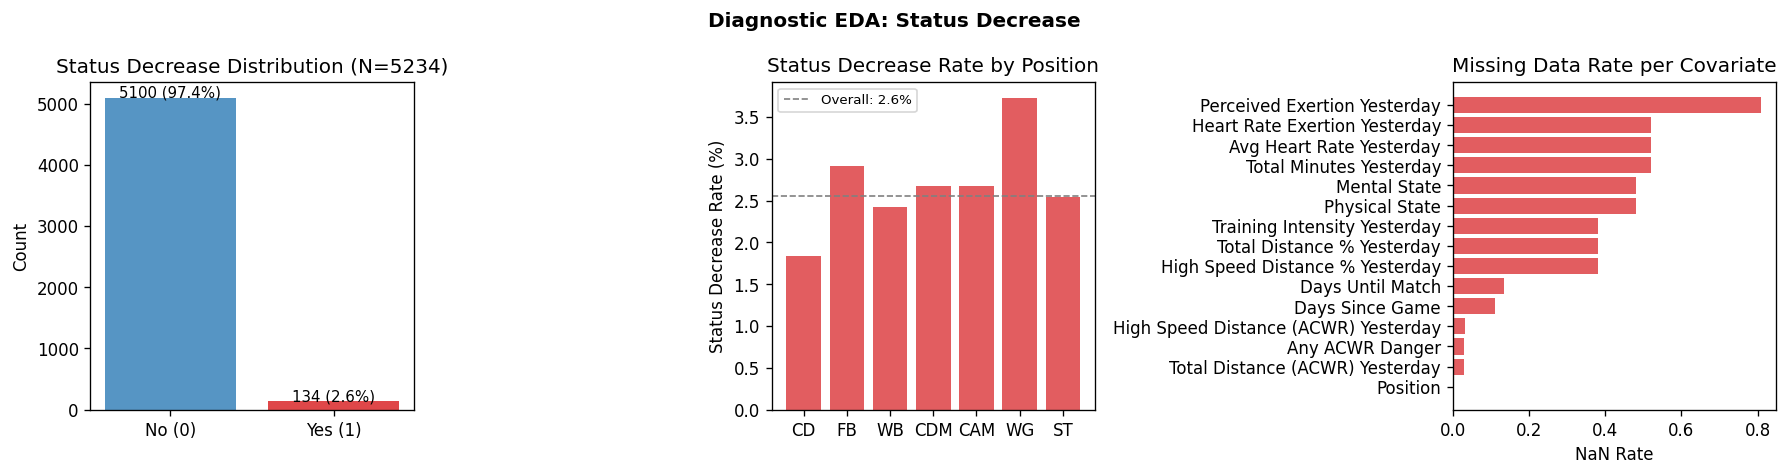

Dataset shape:     (5234, 46)
Status Decrease:   5234 non-NaN
  Positive (1):    134 (2.6%)
  Negative (0):    5100 (97.4%)
  Class ratio:     1:38


In [3]:
# -- Diagnostic EDA: Status Decrease distribution, class balance, correlations --
ROOT = Path('..').resolve()
RTT_PATH = ROOT / 'data' / 'processed' / 'RTT.xlsx'
df_eda = pd.read_excel(RTT_PATH)
df_eda['Date'] = pd.to_datetime(df_eda['Date'])

sd = df_eda['Status Decrease'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class balance
ax = axes[0]
counts = sd.value_counts().sort_index()
ax.bar(['No (0)', 'Yes (1)'], counts.values, color=['#2c7bb6', '#d7191c'], alpha=0.8)
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, f'{v} ({v/len(sd)*100:.1f}%)', ha='center', fontsize=9)
ax.set_ylabel('Count')
ax.set_title(f'Status Decrease Distribution (N={len(sd)})')

# Per-position rate
ax = axes[1]
pos_order = ['CD', 'FB', 'WB', 'CDM', 'CAM', 'WG', 'ST']
df_plot = df_eda[df_eda['Status Decrease'].notna()].copy()
pos_present = [p for p in pos_order if p in df_plot['Position'].values]
rates = df_plot.groupby('Position')['Status Decrease'].mean().reindex(pos_present)
ax.bar(rates.index, rates.values * 100, color='#d7191c', alpha=0.7)
ax.set_ylabel('Status Decrease Rate (%)')
ax.set_title('Status Decrease Rate by Position')
ax.axhline(sd.mean() * 100, color='grey', ls='--', lw=1, label=f'Overall: {sd.mean()*100:.1f}%')
ax.legend(fontsize=8)

# NaN rate per covariate
ax = axes[2]
nan_rates = df_eda[COVARIATES].isnull().mean().sort_values(ascending=True)
ax.barh(nan_rates.index, nan_rates.values, color='#d7191c', alpha=0.7)
ax.set_xlabel('NaN Rate')
ax.set_title('Missing Data Rate per Covariate')

plt.suptitle('Diagnostic EDA: Status Decrease', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Dataset shape:     {df_eda.shape}')
print(f'Status Decrease:   {sd.count()} non-NaN')
print(f'  Positive (1):    {int(sd.sum())} ({sd.mean()*100:.1f}%)')
print(f'  Negative (0):    {int((sd==0).sum())} ({(1-sd.mean())*100:.1f}%)')
print(f'  Class ratio:     1:{int((1-sd.mean())/sd.mean())}')


---
## 2. Experiment — Status Decrease Prediction

Predict next-day Status Decrease from morning covariates.


### 2.1 Run all models × lags × modes

Results stored in `all_results[mode][model_type][lag]`.




In [4]:
all_results = {mode: {m: {} for m in MODELS} for mode in MODES}

for mode in MODES:
    for model_type in MODELS:
        gpu_kwargs = GPU_OVERRIDES.get(model_type, {})
        for lag in LAGS:
            print(f"\n>>> {mode}  {model_type}  lag={lag}")
            all_results[mode][model_type][lag] = run_experiment(
                covariates=COVARIATES,
                lag=lag,
                model_type=model_type,
                mode=mode,
                test_size=TEST_SIZE,
                val_size=VAL_SIZE,
                verbose=True,
                **gpu_kwargs,
            )

print("\nAll experiments complete.")




>>> prediction  log_reg  lag=0
Experiment 3: Short-term Load Response
  Mode: prediction -- morning covariates at t -> Status Decrease at t+1
  Mode:           prediction
  Target:         Status Decrease  (target_horizon=1)
  Model:          log_reg
  Lag:            0
  Covariates:     15
                  . Physical State
                  . Mental State
                  . Total Distance (ACWR) Yesterday
                  . High Speed Distance (ACWR) Yesterday
                  . Any ACWR Danger
                  . Total Distance % Yesterday
                  . High Speed Distance % Yesterday
                  . Training Intensity Yesterday
                  . Perceived Exertion Yesterday
                  . Total Minutes Yesterday
                  . Avg Heart Rate Yesterday
                  . Heart Rate Exertion Yesterday
                  . Days Since Game
                  . Days Until Match
                  . Position
  Test size:      0.2
  Val size:       0.1

  ROC AUC: 

### 2.2 Comparison table




In [5]:
rows = []
for mode in MODES:
    for model_type in MODELS:
        for lag in LAGS:
            m = all_results[mode][model_type][lag]['metrics']
            rows.append({
                'Mode':          mode,
                'Model':         model_type,
                'Lag':           lag,
                'ROC AUC':       round(m['roc_auc'],       4),
                'Avg Prec':      round(m['avg_precision'],  4),
                'F1':            round(m['f1'],             4),
                'Recall':        round(m['recall'],         4),
                'Precision':     round(m['precision'],      4),
                'Prevalence':    round(m['prevalence'],     3),
                'N test':        m['n_test'],
                'N pos':         m['n_positive_test'],
            })

comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))

      Mode    Model  Lag  ROC AUC  Avg Prec     F1  Recall  Precision  Prevalence  N test  N pos
prediction  log_reg    0   0.5901    0.0394 0.0480  0.6667     0.0249       0.019     943     18
prediction  log_reg    1   0.6167    0.0437 0.0514  0.6111     0.0268       0.019     943     18
prediction  log_reg    2   0.6281    0.0351 0.0556  0.6111     0.0291       0.019     943     18
prediction  log_reg    3   0.6156    0.0318 0.0546  0.5556     0.0287       0.019     943     18
prediction  xgboost    0   0.6030    0.0243 0.0179  0.0556     0.0106       0.019     943     18
prediction  xgboost    1   0.5769    0.0827 0.0606  0.1111     0.0417       0.019     943     18
prediction  xgboost    2   0.6157    0.0565 0.0851  0.1111     0.0690       0.019     943     18
prediction  xgboost    3   0.5799    0.0258 0.0357  0.0556     0.0263       0.019     943     18
prediction catboost    0   0.5105    0.0227 0.0350  0.3889     0.0183       0.019     943     18
prediction catboost    1   0.5

**Reading the table:**
- **ROC AUC 0.5** = random; higher is better (not affected by class imbalance).
- **Avg Precision** = area under the PR curve; more sensitive to class imbalance than ROC AUC.
- **Comparison across modes**: if `causal_framing` AUC > `prediction` AUC, same-day load has strong contemporaneous signal; if similar, morning state dominates.


### 2.3 ROC AUC across models, lags, modes




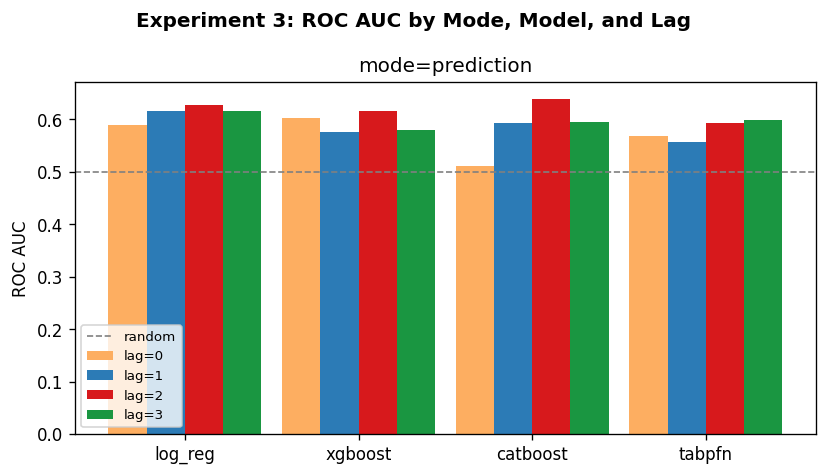

In [6]:
LAG_COLORS = {0: '#fdae61', 1: '#2c7bb6', 2: '#d7191c', 3: '#1a9641'}
n_lags  = len(LAGS)
n_modes = len(MODES)

fig, axes = plt.subplots(1, n_modes, figsize=(7 * n_modes, 4), sharey=True)
if n_modes == 1:
    axes = [axes]

x = np.arange(len(MODELS))
w = 0.22

for ax, mode in zip(axes, MODES):
    for i, lag in enumerate(LAGS):
        offset = (i - (n_lags - 1) / 2) * w
        aucs = [all_results[mode][m][lag]['metrics']['roc_auc'] for m in MODELS]
        ax.bar(x + offset, aucs, w, label=f'lag={lag}', color=LAG_COLORS[lag])
    ax.axhline(0.5, color='grey', ls='--', lw=1, label='random')
    ax.set_xticks(x); ax.set_xticklabels(MODELS)
    ax.set_ylabel('ROC AUC'); ax.set_title(f'mode={mode}')
    ax.legend(fontsize=8)

fig.suptitle('Experiment 3: ROC AUC by Mode, Model, and Lag', fontweight='bold')
plt.tight_layout()
plt.show()


### 2.4 Lag effect




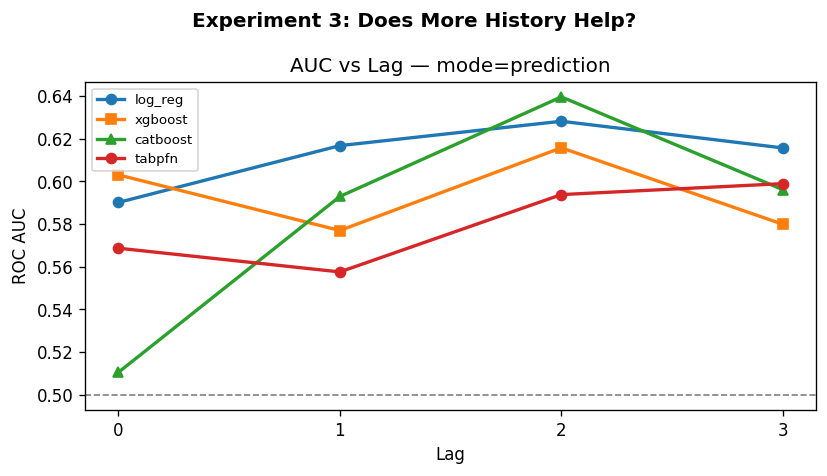

In [7]:
fig, axes = plt.subplots(1, n_modes, figsize=(7 * n_modes, 4), sharey=True)
if n_modes == 1:
    axes = [axes]

markers = ['o', 's', '^']

for ax, mode in zip(axes, MODES):
    for j, model_type in enumerate(MODELS):
        aucs = [all_results[mode][model_type][lag]['metrics']['roc_auc']
                for lag in LAGS]
        ax.plot(LAGS, aucs, marker=markers[j % len(markers)],
                label=model_type, lw=2)
    ax.axhline(0.5, color='grey', ls='--', lw=1)
    ax.set_xlabel('Lag'); ax.set_ylabel('ROC AUC')
    ax.set_title(f'AUC vs Lag — mode={mode}')
    ax.set_xticks(LAGS)
    ax.legend(fontsize=8)

fig.suptitle('Experiment 3: Does More History Help?', fontweight='bold')
plt.tight_layout()
plt.show()

### 2.5 Best model — ROC and PR curves — best prediction-mode model




Best prediction mode: catboost lag=2  AUC=0.6395  AP=0.0319


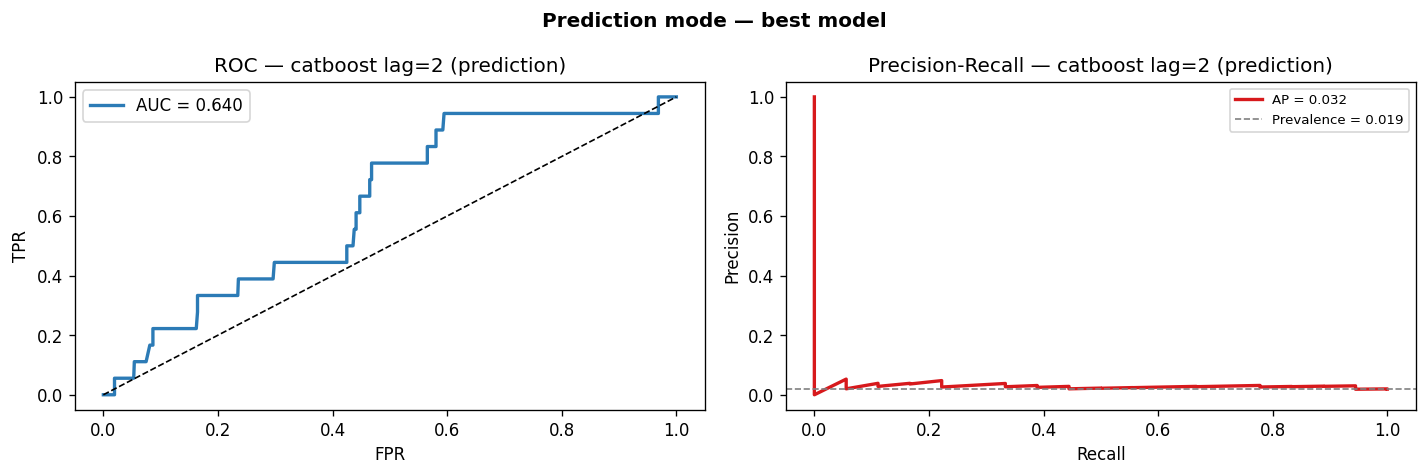

In [8]:
# Best (model, lag) in prediction mode
best_pred = max(
    [(m, l) for m in MODELS for l in LAGS],
    key=lambda ml: all_results['prediction'][ml[0]][ml[1]]['metrics']['roc_auc']
)
bm, bl = best_pred
res = all_results['prediction'][bm][bl]
print(f"Best prediction mode: {bm} lag={bl}  "
      f"AUC={res['metrics']['roc_auc']:.4f}  "
      f"AP={res['metrics']['avg_precision']:.4f}")

y_true = res['y_test_true']
y_prob = res['y_test_pred']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fpr, tpr, _ = roc_curve(y_true, y_prob)
ax = axes[0]
ax.plot(fpr, tpr, color='#2c7bb6', lw=2,
        label=f"AUC = {res['metrics']['roc_auc']:.3f}")
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'ROC — {bm} lag={bl} (prediction)')
ax.legend()

prec, rec, _ = precision_recall_curve(y_true, y_prob)
ax = axes[1]
ax.plot(rec, prec, color='#d7191c', lw=2,
        label=f"AP = {res['metrics']['avg_precision']:.3f}")
ax.axhline(res['metrics']['prevalence'], color='grey', ls='--', lw=1,
           label=f"Prevalence = {res['metrics']['prevalence']:.3f}")
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall — {bm} lag={bl} (prediction)')
ax.legend(fontsize=8)

plt.suptitle('Prediction mode — best model', fontweight='bold')
plt.tight_layout()
plt.show()

### 2.6 Feature importance (best model)


Best model: catboost lag=2  AUC=0.6395
Computing permutation importance (5 repeats, 943 test samples)...


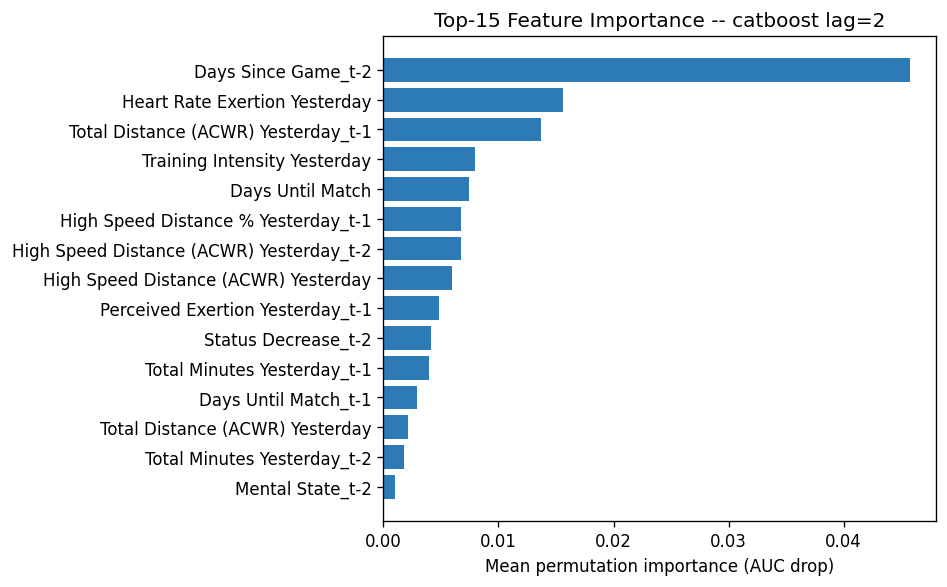

Top 10 features:
                                 feature  importance
                     Days Since Game_t-2    0.045730
           Heart Rate Exertion Yesterday    0.015610
     Total Distance (ACWR) Yesterday_t-1    0.013676
            Training Intensity Yesterday    0.007952
                        Days Until Match    0.007453
     High Speed Distance % Yesterday_t-1    0.006775
High Speed Distance (ACWR) Yesterday_t-2    0.006769
    High Speed Distance (ACWR) Yesterday    0.006006
        Perceived Exertion Yesterday_t-1    0.004829
                     Status Decrease_t-2    0.004174


In [9]:
# Feature importance for the best model using sklearn permutation importance
from sklearn.inspection import permutation_importance as sklearn_perm_imp

print(f'Best model: {bm} lag={bl}  AUC={all_results["prediction"][bm][bl]["metrics"]["roc_auc"]:.4f}')

best_res = all_results['prediction'][bm][bl]
trained = best_res.get('trained_model')
X_test_fi = best_res.get('X_test')
y_test_fi = best_res.get('y_test_true')
fnames_fi = best_res.get('feature_names', [])

# If trained_model/X_test not in results (old script), refit the best model
if trained is None or X_test_fi is None:
    print('trained_model or X_test not cached in results -- refitting best model...')
    refit_res = run_experiment(
        covariates=COVARIATES, lag=bl, model_type=bm, mode='prediction',
        test_size=TEST_SIZE, val_size=VAL_SIZE, verbose=False,
        **GPU_OVERRIDES.get(bm, {}),
    )
    trained = refit_res.get('trained_model')
    X_test_fi = refit_res.get('X_test')
    y_test_fi = refit_res.get('y_test_true')
    fnames_fi = refit_res.get('feature_names', [])

if trained is not None and X_test_fi is not None and y_test_fi is not None:
    print(f'Computing permutation importance (5 repeats, {X_test_fi.shape[0]} test samples)...')
    perm = sklearn_perm_imp(trained, X_test_fi, y_test_fi,
                            n_repeats=5, random_state=42, scoring='roc_auc')
    fn = fnames_fi if len(fnames_fi) == X_test_fi.shape[1] else [f'f_{i}' for i in range(X_test_fi.shape[1])]
    imp_df = pd.DataFrame({
        'feature': fn,
        'importance': perm.importances_mean,
    }).sort_values('importance', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='#2c7bb6')
    ax.set_xlabel('Mean permutation importance (AUC drop)')
    ax.set_title(f'Top-15 Feature Importance -- {bm} lag={bl}')
    plt.tight_layout()
    plt.show()

    print('Top 10 features:')
    print(imp_df.head(10).to_string(index=False))
else:
    print('ERROR: Could not obtain trained model even after refitting.')



## 3. Summary

All experimental findings printed in plain text — scroll through the output of the next cell for the complete results report.




In [10]:
try:
    print("=" * 72)
    print("EXPERIMENT 3 -- RESULTS SUMMARY")
    print("=" * 72)
    print()
    for mode in MODES:
        print(f"MODE: {mode}")
        print("-" * 72)
        print(f"  {'Model':<12} {'Lag':>4} {'AUC':>8} {'AvgPrec':>8} {'F1':>6} {'Prec':>6} {'Rec':>6} {'Acc':>6}")
        for model_type in MODELS:
            for lag in LAGS:
                r = all_results[mode][model_type].get(lag)
                if r is None: continue
                m = r['metrics']
                auc = m.get('roc_auc', 0) or 0
                ap = m.get('avg_precision', 0) or 0
                f1 = m.get('f1', 0) or 0
                prec = m.get('precision', 0) or 0
                rec = m.get('recall', 0) or 0
                acc = m.get('accuracy', 0) or 0
                print(f"  {model_type:<12} {lag:>4} {auc:>8.4f} {ap:>8.4f} {f1:>6.4f} {prec:>6.4f} {rec:>6.4f} {acc:>6.4f}")
        print()
    # Best model
    valid = [(m, l) for m in MODELS for l in LAGS
             if all_results['prediction'][m].get(l) is not None
             and all_results['prediction'][m][l]['metrics'].get('roc_auc') is not None]
    if valid:
        bm_s, bl_s = max(valid, key=lambda ml: all_results['prediction'][ml[0]][ml[1]]['metrics']['roc_auc'])
        bmet = all_results['prediction'][bm_s][bl_s]['metrics']
        print(f"BEST: {bm_s} lag={bl_s}")
        for k, v in bmet.items():
            if isinstance(v, float):
                print(f"  {k:<20} {v:.6f}")
            else:
                print(f"  {k:<20} {v}")
    print("=" * 72)
except NameError:
    print("[Summary] Run experiment cells first.")



EXPERIMENT 3 -- RESULTS SUMMARY

MODE: prediction
------------------------------------------------------------------------
  Model         Lag      AUC  AvgPrec     F1   Prec    Rec    Acc
  log_reg         0   0.5901   0.0394 0.0480 0.0249 0.6667 0.4952
  log_reg         1   0.6167   0.0437 0.0514 0.0268 0.6111 0.5695
  log_reg         2   0.6281   0.0351 0.0556 0.0291 0.6111 0.6034
  log_reg         3   0.6156   0.0318 0.0546 0.0287 0.5556 0.6331
  xgboost         0   0.6030   0.0243 0.0179 0.0106 0.0556 0.8834
  xgboost         1   0.5769   0.0827 0.0606 0.0417 0.1111 0.9343
  xgboost         2   0.6157   0.0565 0.0851 0.0690 0.1111 0.9544
  xgboost         3   0.5799   0.0258 0.0357 0.0263 0.0556 0.9427
  catboost        0   0.5105   0.0227 0.0350 0.0183 0.3889 0.5907
  catboost        1   0.5929   0.0287 0.0389 0.0204 0.4444 0.5811
  catboost        2   0.6395   0.0319 0.0427 0.0224 0.4444 0.6193
  catboost        3   0.5961   0.0275 0.0421 0.0225 0.3333 0.7105
  tabpfn          0